<a href="https://colab.research.google.com/github/Yahir-7/GeoPandas/blob/main/Ennergy_Conflict_Index_Energy_Burden_Percentile_DCxEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3262/1948983590.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged['area'] = merged.geometry.area
/tmp/ipykernel_3262/1948983590.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged['length'] = merged.geometry.length


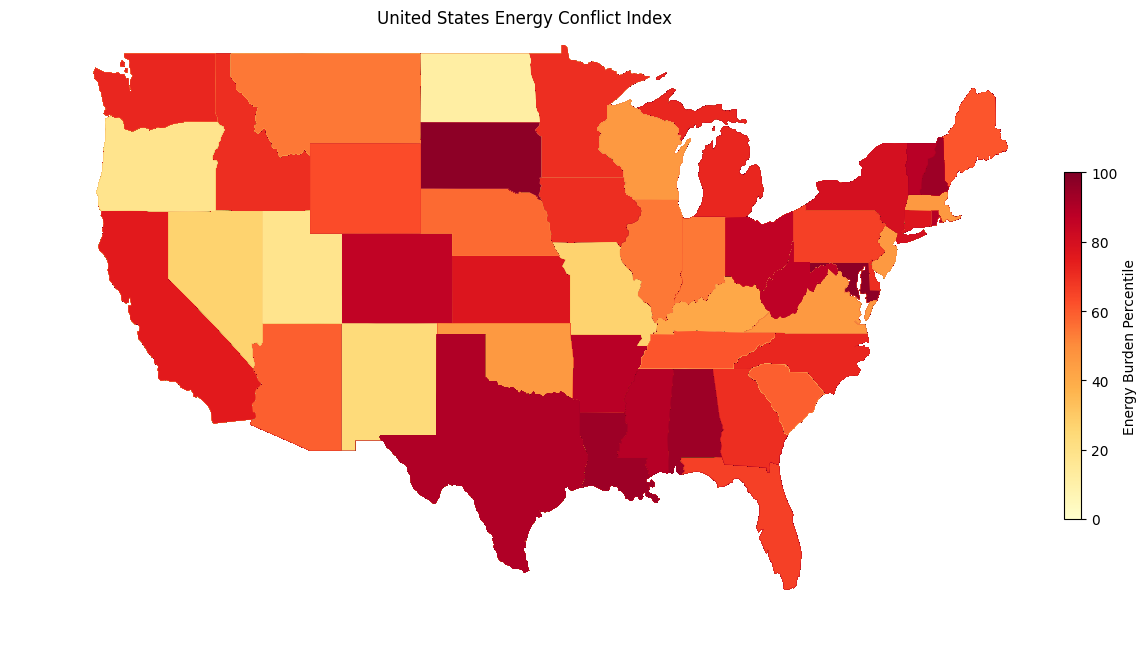

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
!pip install geodatasets
gdf = gpd.read_file('/content/2.0-communities.csv')
file = gpd.GeoDataFrame(gdf)
file = file
#set index to state/territory
state = file.set_index('State/Territory')
state
#filter out these are energy burden 47,48,these are pm2.5 50,51,there are diesal53,54
state = state.drop(state.columns[[50,51,53,54,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,49,52,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134]], axis=1)
state
#need to add url of us map

#world
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data'
state_geo = gpd.read_file(url + '/us-states.json')
state_geo
#merge w my data
merged = state_geo.merge(state, left_on='name', right_on='State/Territory', how='left')
merged
#adding area, boundary, length
merged['area'] = merged.geometry.area
merged['area']

merged['boundary'] = merged.geometry.boundary
merged['boundary']

merged['length'] = merged.geometry.length
merged['length']

merged['Energy burden (percentile)'] = pd.to_numeric(merged['Energy burden (percentile)'], errors='coerce')
#fit plot so it doesn't stretch
fig, ax = plt.subplots(figsize=(16,9))
merged.plot(column ='Energy burden (percentile)', legend=True, ax=ax, cmap='YlOrRd', legend_kwds={'label': "Energy Burden Percentile", 'orientation': "vertical", 'shrink': 0.5, 'pad' :0.02})
ax.set_xlim(-130,-65)
ax.set_ylim(22,50)
ax.set_title('United States Energy Conflict Index')
ax.axis('off')
plt.show()

#

